In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
os.chdir("..")

In [3]:
gdf_results = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")
gdf_population = gpd.read_parquet("data/evaluation/evaluation_raster_population.parquet")

In [4]:
gdf_results["population"] = gdf_population["value_result"].fillna(0)

In [5]:
configurations = [
    "average_time_walk_noon_vuln1_2",
    "average_time_walk_evening_vuln1_20",
    "average_time_bike_evening_vuln5_20",
    "average_time_walk_PT_2",
    "average_time_bike_morning_vuln3_1",
]

In [6]:
gdf_results[configurations]

,average_time_walk_noon_vuln1_2,average_time_walk_evening_vuln1_20,average_time_bike_evening_vuln5_20,average_time_walk_PT_2,average_time_bike_morning_vuln3_1
0,"{'culture': 39.52522566332624, 'education': 45...","{'culture': 40.058352161894675, 'education': 7...","{'culture': 13.655216511464257, 'education': 2...","{'culture': 31.111721501905155, 'education': 3...","{'culture': 11.958888716625069, 'education': 1..."
1,"{'culture': 42.02264971879619, 'education': 47...","{'culture': 42.555776217364624, 'education': 8...","{'culture': 15.718103850975258, 'education': 2...","{'culture': 32.3949505481564, 'education': 35....","{'culture': 13.891900278549118, 'education': 1..."
2,"{'culture': 43.31732195006324, 'education': 48...","{'culture': 43.850448448631674, 'education': 8...","{'culture': 14.056671370697, 'education': 28.3...","{'culture': 34.90381778864196, 'education': 37...","{'culture': 12.395626850521031, 'education': 1..."
3,"{'culture': 36.09305652678682, 'education': 41...","{'culture': 38.481308145008754, 'education': 7...","{'culture': 12.065683707248734, 'education': 2...","{'culture': 31.209482088096866, 'education': 3...","{'culture': 9.960476363467684, 'education': 11..."
4,"{'culture': 39.474417055565965, 'education': 4...","{'culture': 41.8626686737879, 'education': 80....","{'culture': 14.42614129791453, 'education': 27...","{'culture': 33.389070634596, 'education': 36.2...","{'culture': 11.586082869806248, 'education': 1..."
...,...,...,...,...,...
591,"{'culture': 45.72985064828803, 'education': 57...","{'culture': 57.701692148969315, 'education': 5...","{'culture': 35.14069034392558, 'education': 36...","{'culture': 18.971111372694168, 'education': 1...","{'culture': 13.68478482398747, 'education': 21..."
592,"{'culture': 50.14785946358635, 'education': 61...","{'culture': 62.756895772875055, 'education': 6...","{'culture': 38.10287092998366, 'education': 39...","{'culture': 19.0308517460709, 'education': 18....","{'culture': 15.704677188377513, 'education': 2..."
593,"{'culture': 50.454731358894676, 'education': 6...","{'culture': 63.1191673221992, 'education': 65....","{'culture': 38.356047413196016, 'education': 3...","{'culture': 19.184287693725064, 'education': 1...","{'culture': 15.850238403020196, 'education': 2..."
594,"{'culture': 50.02848595409368, 'education': 61...","{'culture': 61.572061542942684, 'education': 6...","{'culture': 37.099004804312706, 'education': 3...","{'culture': 19.79982090533959, 'education': 19...","{'culture': 15.152484870954702, 'education': 2..."


In [7]:
gdf_results["average_time_walk_noon_vuln1_2"].apply(lambda x: np.average(list(x.values())))

0      34.132644
1      36.630068
2      38.203679
3      32.457252
4      35.838613
         ...    
591    29.940551
592    32.708498
593    33.015370
594    31.589847
595    36.966328
Name: average_time_walk_noon_vuln1_2, Length: 596, dtype: float64

In [8]:
result = {}

for configuration in configurations:
    gdf_results[configuration] = gdf_results[configuration].apply(lambda x: np.mean(list(x.values())))
    population_average = np.average(gdf_results[configuration], weights=gdf_results["population"])
    result["population_average"] = result.get("population_average", []) + [population_average]
    variance = np.average((gdf_results[configuration] - population_average)**2, weights=gdf_results["population"])
    result["population_std"] = result.get("population_std", []) + [np.sqrt(variance)]

    
    result["hexagon_average"] = result.get("hexagon_average", []) + [gdf_results[configuration].mean()]
    result["hexagon_std"] = result.get("hexagon_std", []) + [gdf_results[configuration].std()]


In [9]:
df = pd.DataFrame(result, index=configurations)
df

,population_average,population_std,hexagon_average,hexagon_std
average_time_walk_noon_vuln1_2,9.633502,8.860672,21.783424,17.049103
average_time_walk_evening_vuln1_20,15.907292,11.714690,32.194764,21.233437
average_time_bike_evening_vuln5_20,8.058377,7.018649,16.398554,12.631587
average_time_walk_PT_2,4.872220,4.282749,12.372955,9.564315
average_time_bike_morning_vuln3_1,3.446818,3.548291,7.820813,6.718352


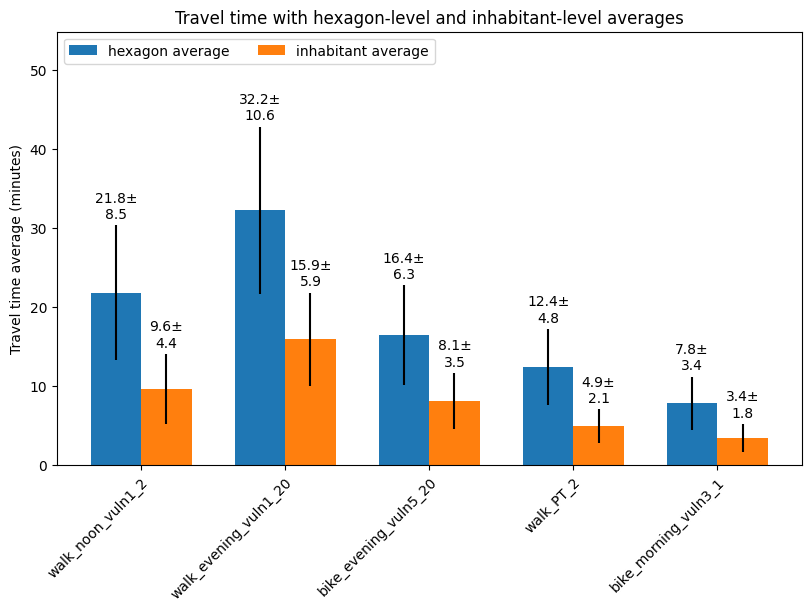

In [ ]:
n_s = {
    "hexagon average": list(df["hexagon_average"]),
    "inhabitant average": list(df["population_average"]),
}
standard_deviations = {
    "hexagon average": list(df["hexagon_std"]),
    "inhabitant average": list(df["population_std"]),
}

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.7  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(8, 6))

max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement, 1)
    y_errs = np.array(standard_deviations.get(attribute)) / 2

    max_value = max(max_value, max(measurement) + max(y_errs))
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, yerr=y_errs)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}±\n{err:.1f}" for val, err in zip(measurement, y_errs)],
        padding=3,
    )
    multiplier += 1

ax.set_ylabel("Travel time average (minutes)")
ax.set_title("Travel time with hexagon-level and inhabitant-level averages")
ax.set_xticks(
    x + width / 2,
    [configuration.replace("average_time_", "") for configuration in configurations],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)
ax.legend(loc="upper left", ncols=2)
ax.set_ylim(0, max_value + 12)
plt.show()